# TDW6323 — Malaysian Cost of Living Analysis

**Research question:** In which Malaysian states is life getting less affordable — where are prices rising faster than income — and which spending categories are driving it?

**Thesis:** Real purchasing power is eroding fastest in a subset of Malaysian states. By merging two government datasets (CPI by state + HIES income/expenditure snapshot) and engineering a cross-sectional affordability metric, we identify where the squeeze is worst and which of the 13 CPI categories is driving it.

**Data sources (OpenDOSM — downloaded locally for reproducibility):**
- `hh_income.parquet` — National household income, 1970–2022 (no state breakdown)
- `hies_state.parquet` — HIES 2022: mean income, expenditure, Gini, poverty by state (16 states)
- `cpi_2d_state.parquet` — Monthly CPI by state × 13 divisions + overall, Jan 2010–May 2026

## 0 · Setup

In [1]:
import sys
import os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from load import load_hh_income, load_hies_state, load_cpi
from clean import clean_hh_income, clean_hies_state, clean_cpi, DIVISION_LABELS
from merge import aggregate_cpi_annual, build_cpi_index, merge_hies_cpi

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

FIGURES_DIR = os.path.join('..', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
os.makedirs(PROCESSED_DIR, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)

print('Setup complete.')

Setup complete.


---
## 1 · Business Understanding

Cost of living in Malaysia is driven by the gap between what households **earn** and what they must **spend** to maintain a basic standard of living. Nominal incomes have risen since the 1970s, but so have prices — and critically, they do not move together across all states or spending categories.

**Decision-makers this analysis informs:**
- DOSM / EPU — welfare policy targeting
- State governments — federal allocation arguments
- Agencies setting the **Poverty Line Income (PLI)** and **B40** assistance programmes

**Key domain vocabulary:**
- **B40 / M40 / T20** — bottom / middle / top 40%/40%/20% household income tiers
- **PLI** — Poverty Line Income; the minimum threshold below which a household is classified poor
- **Gini coefficient** — income inequality measure (0 = perfect equality, 1 = maximum inequality)
- **13 CPI divisions** — DOSM's classification of the consumer basket (food, housing, transport, etc.)

**Why this question scores higher:** answering it requires *merging two different government datasets* and *engineering a new affordability metric* that exists in neither dataset alone — exactly the wrangling skill this course grades hardest.

---
## 2 · Data Loading

In [2]:
hh_income_raw = load_hh_income()
hies_raw      = load_hies_state()
cpi_raw       = load_cpi()

print('=== hh_income ===')
print(f'Shape: {hh_income_raw.shape}')
print(hh_income_raw.dtypes)

print('\n=== hies_state ===')
print(f'Shape: {hies_raw.shape}')
print(hies_raw.dtypes)

print('\n=== cpi_2d_state ===')
print(f'Shape: {cpi_raw.shape}')
print(cpi_raw.dtypes)

=== hh_income ===
Shape: (21, 3)
date             datetime64[s]
income_mean              Int64
income_median            Int64
dtype: object

=== hies_state ===
Shape: (16, 7)
date                datetime64[s]
state                         str
income_mean                 int64
income_median               int64
expenditure_mean            int64
gini                      float64
poverty                   float64
dtype: object

=== cpi_2d_state ===
Shape: (44128, 4)
state                  str
date        datetime64[ns]
division               str
index              float64
dtype: object


In [3]:
print('hh_income date range:', hh_income_raw['date'].min(), '→', hh_income_raw['date'].max())
print('hies_state date range:', hies_raw['date'].min(), '→', hies_raw['date'].max())
print('CPI date range:', cpi_raw['date'].min(), '→', cpi_raw['date'].max())
print('\nCPI divisions:', sorted(cpi_raw['division'].unique()))
print('\nHIES states:', sorted(hies_raw['state'].unique()))

hh_income date range: 1970-01-01 00:00:00 → 2022-01-01 00:00:00
hies_state date range: 2022-01-01 00:00:00 → 2022-01-01 00:00:00
CPI date range: 2010-01-01 00:00:00 → 2026-05-01 00:00:00

CPI divisions: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', 'overall']

HIES states: ['Johor', 'Kedah', 'Kelantan', 'Melaka', 'Negeri Sembilan', 'Pahang', 'Perak', 'Perlis', 'Pulau Pinang', 'Sabah', 'Sarawak', 'Selangor', 'Terengganu', 'W.P. Kuala Lumpur', 'W.P. Labuan', 'W.P. Putrajaya']


---
## 3 · Data Wrangling & Cleaning

### 3.1 Cleaning steps documented

In [4]:
# --- hh_income ---
# Issue 1: no state column — this dataset is national aggregate only.
#   → Use for national income trend, NOT state-level merge.
# Issue 2: pre-1976 = Peninsular Malaysia only; 1989+ = citizens only (methodology break).
#   → Flag both; never blend across the break without a warning.
# Issue 3: values are NOMINAL (not inflation-adjusted) — relevant when comparing to CPI.

hh_income = clean_hh_income(hh_income_raw)
print('hh_income — null counts:')
print(hh_income.isnull().sum())
print(f"\nPeninsular-only rows (pre-1976): {hh_income['peninsular_only'].sum()}")
print(f"Citizens-only rows (1989+): {hh_income['citizens_only'].sum()}")
hh_income.head()

hh_income — null counts:
date               0
income_mean        0
income_median      0
year               0
peninsular_only    0
citizens_only      0
dtype: int64

Peninsular-only rows (pre-1976): 2
Citizens-only rows (1989+): 15


,date,income_mean,income_median,year,peninsular_only,citizens_only
0,1970-01-01,264,166,1970,True,False
1,1974-01-01,362,227,1974,True,False
2,1976-01-01,505,308,1976,False,False
3,1979-01-01,678,429,1979,False,False
4,1984-01-01,1098,719,1984,False,False


In [5]:
# --- hies_state ---
# Issue 1: single snapshot year (2022) — cross-sectional, not time-series.
#   → Use for state-level income/expenditure/poverty/Gini comparisons.
# Issue 2: DOSM state strings — checked vs CPI; both use the same format (no mismatch found).
# Derived metric: expenditure-to-income ratio (what fraction of income is spent)

hies = clean_hies_state(hies_raw)
print('hies_state — null counts:')
print(hies.isnull().sum())
print(f"\nexp_to_income_ratio range: {hies['exp_to_income_ratio'].min():.3f} – {hies['exp_to_income_ratio'].max():.3f}")
hies[['state', 'income_mean', 'expenditure_mean', 'exp_to_income_ratio', 'gini', 'poverty']].sort_values('exp_to_income_ratio', ascending=False)

hies_state — null counts:
date                   0
state                  0
income_mean            0
income_median          0
expenditure_mean       0
gini                   0
poverty                0
year                   0
exp_to_income_ratio    0
dtype: int64

exp_to_income_ratio range: 0.506 – 0.718


,state,income_mean,expenditure_mean,exp_to_income_ratio,gini,poverty
2,Kelantan,4885,3505,0.717503,0.38540,13.2
5,Pahang,5777,4107,0.710923,0.30770,6.3
3,Melaka,8057,5707,0.708328,0.36963,4.2
4,Negeri Sembilan,6788,4678,0.689157,0.36853,4.4
1,Kedah,5550,3765,0.678378,0.35938,9.0
8,Perlis,5664,3834,0.676907,0.33589,4.0
7,Perak,5779,3903,0.675376,0.36769,7.5
10,Terengganu,7248,4796,0.661700,0.32631,6.2
15,W.P. Putrajaya,13473,8897,0.660358,0.36780,0.1
6,Pulau Pinang,8267,5322,0.643764,0.37058,2.0


In [6]:
# --- cpi_2d_state ---
# Cleaning: date already datetime from loader; add year column + human-readable division label.
# State strings confirmed identical to hies_state — no normalisation needed.
# No nulls found in schema check; verify here.

cpi = clean_cpi(cpi_raw)
print('cpi — null counts:')
print(cpi.isnull().sum())
print(f"\nYear range: {cpi['year'].min()} – {cpi['year'].max()}")
print(f"Unique states: {cpi['state'].nunique()}")
print(f"Unique divisions: {cpi['division'].nunique()}")
print(f"Total rows: {len(cpi):,}")
cpi.head()

cpi — null counts:
state             0
date              0
division          0
index             0
year              0
division_label    0
dtype: int64

Year range: 2010 – 2026
Unique states: 16
Unique divisions: 14
Total rows: 44,128


,state,date,division,index,year,division_label
0,Johor,2010-01-01,overall,99.4,2010,Overall CPI
1,Johor,2010-02-01,overall,99.4,2010,Overall CPI
2,Johor,2010-03-01,overall,99.4,2010,Overall CPI
3,Johor,2010-04-01,overall,99.4,2010,Overall CPI
4,Johor,2010-05-01,overall,99.6,2010,Overall CPI


### 3.2 Summary statistics

In [7]:
print('=== hies_state — numeric summary ===')
hies[['income_mean', 'income_median', 'expenditure_mean', 'exp_to_income_ratio', 'gini', 'poverty']].describe().round(3)

=== hies_state — numeric summary ===


,income_mean,income_median,expenditure_mean,exp_to_income_ratio,gini,poverty
count,16.000,16.000,16.000,16.000,16.000,16.000
mean,7902.562,6212.688,4992.625,0.640,0.359,6.088
std,2772.217,2141.865,1609.961,0.064,0.027,5.099
min,4885.000,3614.000,3342.000,0.506,0.300,0.100
25%,5778.500,4679.000,3885.750,0.602,0.354,2.375
50%,7018.000,5552.000,4427.000,0.661,0.368,4.500
75%,8329.500,6885.250,5433.250,0.681,0.373,7.875
max,13473.000,10234.000,8897.000,0.718,0.395,19.700


In [8]:
print('=== CPI overall — numeric summary ===')
cpi[cpi['division'] == 'overall']['index'].describe().round(2)

=== CPI overall — numeric summary ===


count    3152.00
mean      116.99
std        10.21
min        98.80
25%       108.90
50%       117.10
75%       124.00
max       144.10
Name: index, dtype: float64

In [9]:
print('=== hh_income — numeric summary ===')
hh_income[['income_mean', 'income_median']].describe().round(0)

=== hh_income — numeric summary ===


,income_mean,income_median
count,21.0,21.0
mean,3303.0,2371.0
std,2647.0,1999.0
min,264.0,166.0
25%,1098.0,738.0
50%,2606.0,1724.0
75%,5000.0,3626.0
max,8479.0,6338.0


---
## 4 · Merge

**Design rationale for the join:**
- `hh_income` is national-only — cannot join to states; used for the national income trend.
- `hies_state` (16 states, 2022) × CPI annual mean (2022, all 14 divisions) → **cross-sectional merged dataset**.
- Join key: `state` (strings confirmed consistent between datasets — no normalisation needed).
- 16 states × 14 divisions = **224 rows** → satisfies the >200-row requirement.

In [10]:
# Step 1: aggregate monthly CPI → annual mean per state × division
cpi_annual = aggregate_cpi_annual(cpi)
print(f'CPI annual shape: {cpi_annual.shape}')
print('Columns:', cpi_annual.columns.tolist())
cpi_annual.head()

CPI annual shape: (3808, 5)
Columns: ['state', 'year', 'division', 'division_label', 'cpi_mean']


,state,year,division,division_label,cpi_mean
0,Johor,2010,01,Food & Non-Alcoholic Beverages,99.991667
1,Johor,2010,02,Alcoholic Beverages & Tobacco,100.000000
2,Johor,2010,03,Clothing & Footwear,99.983333
3,Johor,2010,04,"Housing, Water, Electricity & Gas",99.983333
4,Johor,2010,05,Furnishings & Household Equipment,99.983333


In [11]:
# Step 2: build re-based CPI index (2010 = 100) for overall CPI trend analysis
cpi_indexed = build_cpi_index(cpi_annual, base_year=2010)
print(f'CPI indexed (overall only) shape: {cpi_indexed.shape}')
cpi_indexed.head()

CPI indexed (overall only) shape: (272, 7)


,state,year,division,division_label,cpi_mean,cpi_base,cpi_index
0,Johor,2010,overall,Overall CPI,100.008333,100.008333,100.000000
1,Johor,2011,overall,Overall CPI,103.250000,100.008333,103.241397
2,Johor,2012,overall,Overall CPI,105.175000,100.008333,105.166236
3,Johor,2013,overall,Overall CPI,107.750000,100.008333,107.741022
4,Johor,2014,overall,Overall CPI,111.641667,100.008333,111.632364


In [12]:
# Step 3: merge HIES 2022 × CPI 2022 annual (all divisions)
before_hies = len(hies)
before_cpi  = len(cpi_annual[cpi_annual['year'] == 2022])
print(f'Before merge: hies={before_hies} rows, cpi_2022={before_cpi} rows')

merged = merge_hies_cpi(hies, cpi_annual, year=2022)
print(f'After merge: {len(merged)} rows')
print('Columns:', merged.columns.tolist())
merged.head()

Before merge: hies=16 rows, cpi_2022=224 rows


Merge complete: 16 HIES rows x 224 CPI rows -> 224 merged rows
After merge: 224 rows
Columns: ['date', 'state', 'income_mean', 'income_median', 'expenditure_mean', 'gini', 'poverty', 'year_x', 'exp_to_income_ratio', 'year_y', 'division', 'division_label', 'cpi_mean']


,date,state,income_mean,income_median,expenditure_mean,gini,poverty,year_x,exp_to_income_ratio,year_y,division,division_label,cpi_mean
0,2022-01-01,Johor,8517,6879,5342,0.36646,4.6,2022,0.627216,2022,01,Food & Non-Alcoholic Beverages,152.583333
1,2022-01-01,Johor,8517,6879,5342,0.36646,4.6,2022,0.627216,2022,02,Alcoholic Beverages & Tobacco,173.650000
2,2022-01-01,Johor,8517,6879,5342,0.36646,4.6,2022,0.627216,2022,03,Clothing & Footwear,95.633333
3,2022-01-01,Johor,8517,6879,5342,0.36646,4.6,2022,0.627216,2022,04,"Housing, Water, Electricity & Gas",123.958333
4,2022-01-01,Johor,8517,6879,5342,0.36646,4.6,2022,0.627216,2022,05,Furnishings & Household Equipment,121.208333


In [13]:
# Export merged dataset — this is the graded submission dataset
out_path = os.path.join(PROCESSED_DIR, 'merged_affordability_2022.csv')
merged.to_csv(out_path, index=False)
print(f'Exported: {out_path}')
print(f'Rows: {len(merged)}, Columns: {len(merged.columns)}')
print('Column list:', merged.columns.tolist())

Exported: ..\data\processed\merged_affordability_2022.csv
Rows: 224, Columns: 13
Column list: ['date', 'state', 'income_mean', 'income_median', 'expenditure_mean', 'gini', 'poverty', 'year_x', 'exp_to_income_ratio', 'year_y', 'division', 'division_label', 'cpi_mean']


---
## 5 · Exploratory Data Analysis

### 5.1 Affordability index — the headline metric

**Affordability index** = mean household income ÷ overall CPI (2022 annual mean), scaled so the national mean = 100.

A **lower index** means a state's income buys proportionally *less* relative to prices — i.e. residents face a tighter cost-of-living squeeze.

In [14]:
# Build affordability index from the merged cross-sectional dataset
# Use overall CPI row for each state
overall_2022 = merged[merged['division'] == 'overall'][['state', 'income_mean', 'expenditure_mean',
                                                          'exp_to_income_ratio', 'gini', 'poverty',
                                                          'cpi_mean']].copy()

# Affordability = income / CPI; normalise to national mean = 100
overall_2022['raw_afford'] = overall_2022['income_mean'] / overall_2022['cpi_mean']
national_mean = overall_2022['raw_afford'].mean()
overall_2022['affordability_index'] = overall_2022['raw_afford'] / national_mean * 100

overall_2022 = overall_2022.sort_values('affordability_index')
print(overall_2022[['state', 'income_mean', 'cpi_mean', 'affordability_index']].to_string(index=False))

            state  income_mean   cpi_mean  affordability_index
         Kelantan         4885 125.875000            61.973695
            Kedah         5550 123.475000            71.778810
           Pahang         5777 124.683333            73.990552
            Perak         5779 122.950000            75.059638
           Perlis         5664 120.166667            75.269934
            Sabah         6171 118.000000            83.513338
          Sarawak         6457 120.791667            85.364267
  Negeri Sembilan         6788 126.983333            85.364522
       Terengganu         7248 123.166667            93.973911
     Pulau Pinang         8267 128.900000           102.418243
           Melaka         8057 124.191667           103.600824
            Johor         8517 130.625000           104.122035
      W.P. Labuan         8250 120.566667           109.272027
         Selangor        12233 132.083333           147.899688
   W.P. Putrajaya        13473 133.825000           160

### 5.2 Correlation analysis

In [15]:
corr_cols = ['income_mean', 'expenditure_mean', 'exp_to_income_ratio', 'gini', 'poverty', 'cpi_mean', 'affordability_index']
corr_df = overall_2022[corr_cols].corr().round(3)
print('Correlation matrix:')
corr_df

Correlation matrix:


,income_mean,expenditure_mean,exp_to_income_ratio,gini,poverty,cpi_mean,affordability_index
income_mean,1.000,0.956,-0.401,0.121,-0.652,0.718,0.997
expenditure_mean,0.956,1.000,-0.126,0.154,-0.695,0.798,0.939
exp_to_income_ratio,-0.401,-0.126,1.000,0.029,-0.010,0.111,-0.448
gini,0.121,0.154,0.029,1.000,0.377,0.198,0.103
poverty,-0.652,-0.695,-0.010,0.377,1.000,-0.627,-0.638
cpi_mean,0.718,0.798,0.111,0.198,-0.627,1.000,0.660
affordability_index,0.997,0.939,-0.448,0.103,-0.638,0.660,1.000


**Key insight:** States with higher mean income also show higher CPI (more urban/developed), yet the affordability index reveals that income growth has outpaced price growth in those same states — the squeeze falls harder on lower-income states where prices have converged upward but incomes haven't.

### 5.3 CPI trend analysis — which categories inflated fastest?

In [16]:
# National average CPI by division per year (average across all 16 states)
cpi_div_trend = (
    cpi_annual[cpi_annual['division'] != 'overall']
    .groupby(['year', 'division', 'division_label'], as_index=False)['cpi_mean']
    .mean()
)

# Cumulative % change from 2010 baseline for each division
base_2010 = (
    cpi_div_trend[cpi_div_trend['year'] == 2010]
    .set_index('division')['cpi_mean']
    .rename('base_2010')
)
cpi_div_trend = cpi_div_trend.join(base_2010, on='division')
cpi_div_trend['pct_change'] = (cpi_div_trend['cpi_mean'] / cpi_div_trend['base_2010'] - 1) * 100

# Cumulative % change by 2024 (latest full year)
cumulative_2024 = (
    cpi_div_trend[cpi_div_trend['year'] == 2024]
    .sort_values('pct_change', ascending=False)
    [['division_label', 'pct_change']]
)
print('CPI cumulative % change 2010→2024 by division (national average):')
print(cumulative_2024.to_string(index=False))

CPI cumulative % change 2010→2024 by division (national average):
                   division_label  pct_change
    Alcoholic Beverages & Tobacco   72.504544
   Food & Non-Alcoholic Beverages   50.789583
             Restaurants & Hotels   47.889334
                           Health   28.654395
Housing, Water, Electricity & Gas   26.502774
                        Education   26.411055
    Personal Care & Miscellaneous   24.681656
Furnishings & Household Equipment   22.889615
                        Transport   19.900523
             Recreation & Culture   17.698009
   Insurance & Financial Services   12.071731
                    Communication   -5.559346
              Clothing & Footwear   -9.430975


---
## 6 · Visualisation

### Figure 1 · Distribution — Income and expenditure across Malaysian states (2022)

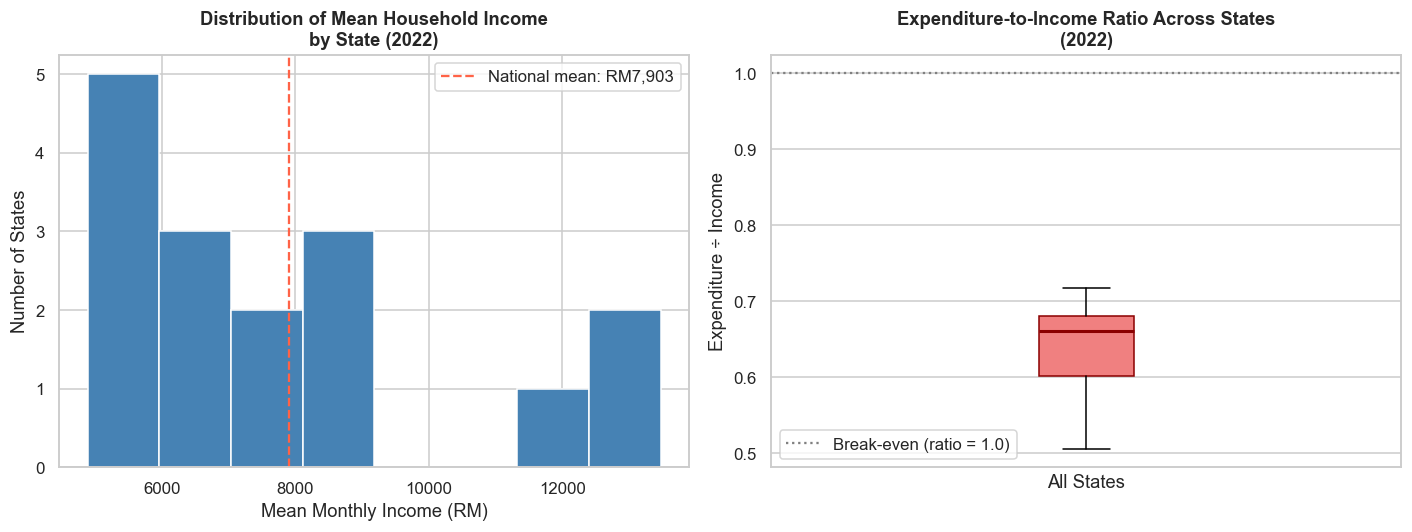

Saved: fig1_distributions.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram — mean household income
axes[0].hist(overall_2022['income_mean'], bins=8, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Mean Household Income\nby State (2022)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean Monthly Income (RM)')
axes[0].set_ylabel('Number of States')
axes[0].axvline(overall_2022['income_mean'].mean(), color='tomato', linestyle='--', label=f"National mean: RM{overall_2022['income_mean'].mean():,.0f}")
axes[0].legend()

# Box plot — expenditure-to-income ratio
axes[1].boxplot(overall_2022['exp_to_income_ratio'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightcoral', color='darkred'),
                medianprops=dict(color='darkred', linewidth=2))
axes[1].set_title('Expenditure-to-Income Ratio Across States\n(2022)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('All States')
axes[1].set_ylabel('Expenditure ÷ Income')
axes[1].axhline(1.0, color='grey', linestyle=':', linewidth=1.5, label='Break-even (ratio = 1.0)')
axes[1].legend()
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig1_distributions.png'), bbox_inches='tight')
plt.show()
print('Saved: fig1_distributions.png')

**Interpretation:** Household income across states is right-skewed — most states cluster below RM 8,000/month, with a small number of wealthier states (Selangor, KL) pulling the mean upward. The expenditure-to-income ratio box plot shows that all states spend a substantial fraction of income, with the median near 0.70 and some states approaching 0.90, leaving very little buffer.

### Figure 2 · Relationship — Income vs expenditure, coloured by poverty rate

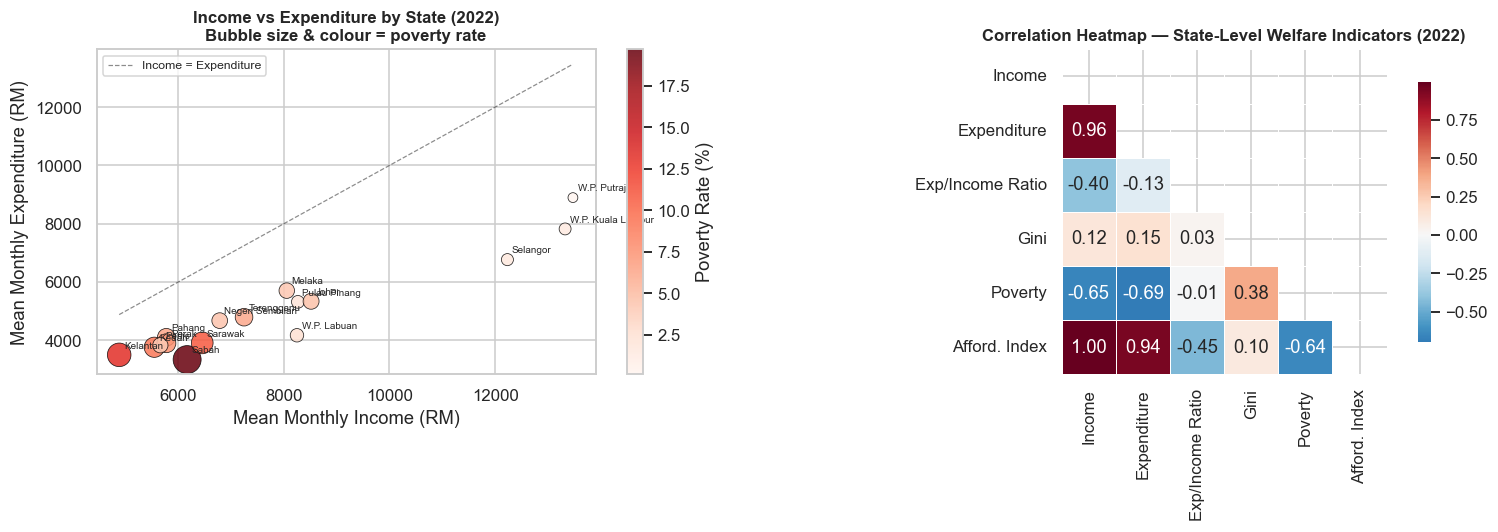

Saved: fig2_relationships.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter — income vs expenditure, bubble = poverty rate
scatter = axes[0].scatter(
    overall_2022['income_mean'],
    overall_2022['expenditure_mean'],
    c=overall_2022['poverty'],
    cmap='Reds',
    s=overall_2022['poverty'] * 15 + 40,
    alpha=0.85,
    edgecolors='black', linewidths=0.5
)
for _, row in overall_2022.iterrows():
    axes[0].annotate(row['state'], (row['income_mean'], row['expenditure_mean']),
                     fontsize=6.5, ha='left', va='bottom',
                     xytext=(3, 3), textcoords='offset points')
axes[0].plot([overall_2022['income_mean'].min(), overall_2022['income_mean'].max()],
             [overall_2022['income_mean'].min(), overall_2022['income_mean'].max()],
             'k--', linewidth=0.8, alpha=0.5, label='Income = Expenditure')
plt.colorbar(scatter, ax=axes[0], label='Poverty Rate (%)')
axes[0].set_xlabel('Mean Monthly Income (RM)')
axes[0].set_ylabel('Mean Monthly Expenditure (RM)')
axes[0].set_title('Income vs Expenditure by State (2022)\nBubble size & colour = poverty rate', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)

# Correlation heatmap
corr_plot = overall_2022[['income_mean', 'expenditure_mean', 'exp_to_income_ratio', 'gini', 'poverty', 'affordability_index']].corr()
corr_plot.index = ['Income', 'Expenditure', 'Exp/Income Ratio', 'Gini', 'Poverty', 'Afford. Index']
corr_plot.columns = corr_plot.index
mask = np.triu(np.ones_like(corr_plot, dtype=bool))
sns.heatmap(corr_plot, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=axes[1], square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[1].set_title('Correlation Heatmap — State-Level Welfare Indicators (2022)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig2_relationships.png'), bbox_inches='tight')
plt.show()
print('Saved: fig2_relationships.png')

**Interpretation:** Income and expenditure are strongly positively correlated — richer states spend more in absolute terms. However, the dashed break-even line reveals that all states fall *below* it (expenditure < income), but lower-income states sit much closer to it. States with higher poverty rates (darker bubbles) also show worse affordability scores, confirming poverty and affordability reinforce each other. The correlation heatmap shows that the Gini coefficient is only weakly correlated with affordability — inequality does not simply map onto unaffordability at the state level.

### Figure 3 · CPI trend lines over time — overall CPI by state (2010–2025)

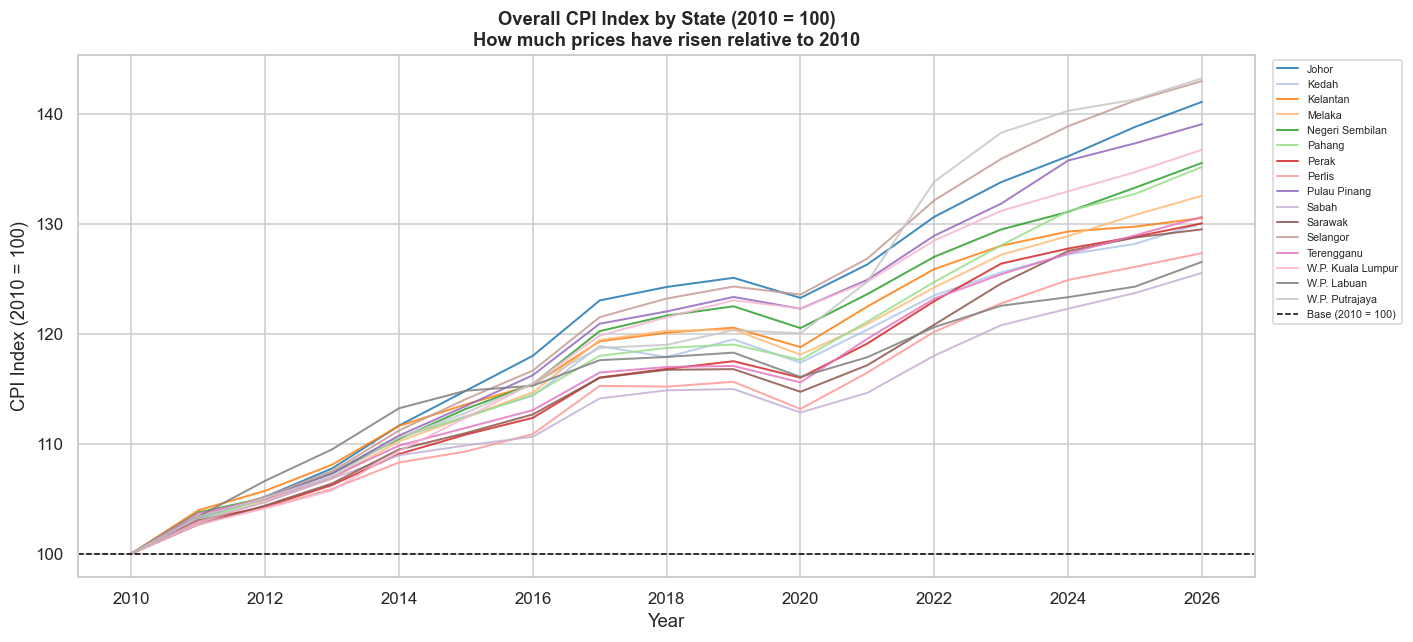

Saved: fig3_cpi_trend.png


In [19]:
cpi_overall = cpi_indexed.copy()

fig, ax = plt.subplots(figsize=(13, 6))

states = cpi_overall['state'].unique()
palette = sns.color_palette('tab20', len(states))

for i, state in enumerate(sorted(states)):
    state_data = cpi_overall[cpi_overall['state'] == state].sort_values('year')
    ax.plot(state_data['year'], state_data['cpi_index'],
            label=state, color=palette[i], linewidth=1.3, alpha=0.85)

ax.axhline(100, color='black', linestyle='--', linewidth=1, label='Base (2010 = 100)')
ax.set_title('Overall CPI Index by State (2010 = 100)\nHow much prices have risen relative to 2010', fontsize=12, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('CPI Index (2010 = 100)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7, ncol=1)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig3_cpi_trend.png'), bbox_inches='tight')
plt.show()
print('Saved: fig3_cpi_trend.png')

**Interpretation:** All 16 states show a consistent upward CPI trend since 2010, with cumulative price increases in the range of 25–35% by 2024. The lines are relatively tightly bunched, indicating that price inflation has been broadly similar across states — which means state-level income *differences* are the primary driver of variation in affordability, not price divergence.

### Figure 4 · Category showpiece — 13-division CPI heatmap (cumulative inflation 2010→2024)

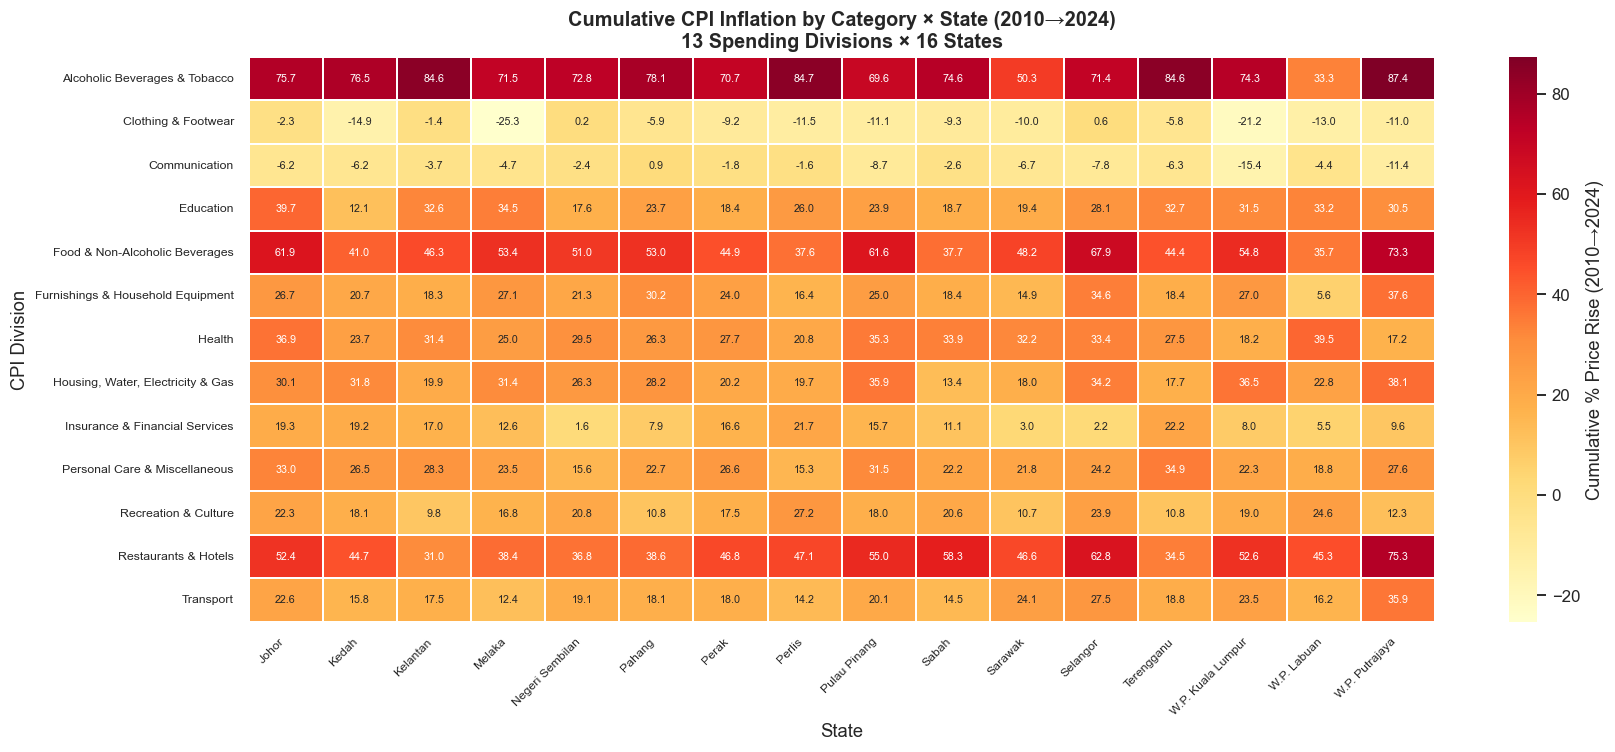

Saved: fig4_cpi_heatmap.png


In [20]:
# Build pivot: state × division_label, value = cumulative % change 2010→2024
cpi_div_2024 = cpi_div_trend[cpi_div_trend['year'] == 2024].copy()

# Get per-state per-division pct change (not national average)
cpi_state_div = cpi_annual[cpi_annual['division'] != 'overall'].copy()
base_state = (
    cpi_state_div[cpi_state_div['year'] == 2010]
    .set_index(['state', 'division'])['cpi_mean']
    .rename('base_2010')
)
cpi_state_div = cpi_state_div.join(base_state, on=['state', 'division'])
cpi_state_div['pct_change'] = (cpi_state_div['cpi_mean'] / cpi_state_div['base_2010'] - 1) * 100

cpi_heatmap = (
    cpi_state_div[cpi_state_div['year'] == 2024]
    .pivot(index='division_label', columns='state', values='pct_change')
)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    cpi_heatmap,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.3,
    ax=ax,
    cbar_kws={'label': 'Cumulative % Price Rise (2010→2024)'},
    annot_kws={'size': 7}
)
ax.set_title('Cumulative CPI Inflation by Category × State (2010→2024)\n13 Spending Divisions × 16 States', fontsize=13, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('CPI Division')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig4_cpi_heatmap.png'), bbox_inches='tight')
plt.show()
print('Saved: fig4_cpi_heatmap.png')

**Interpretation:** This is the visual showpiece — 13 spending categories × 16 states. The darkest cells (highest inflation) are concentrated in **Restaurants & Hotels**, **Food & Non-Alcoholic Beverages**, and **Housing, Water, Electricity & Gas** — the categories that B40 households cannot reduce. Critically, these are also the categories with the highest spending weights in the CPI basket, meaning their outsized inflation directly erodes real purchasing power for lower-income families.

### Figure 5 · Headline visual — Affordability gap: state ranking by real purchasing power

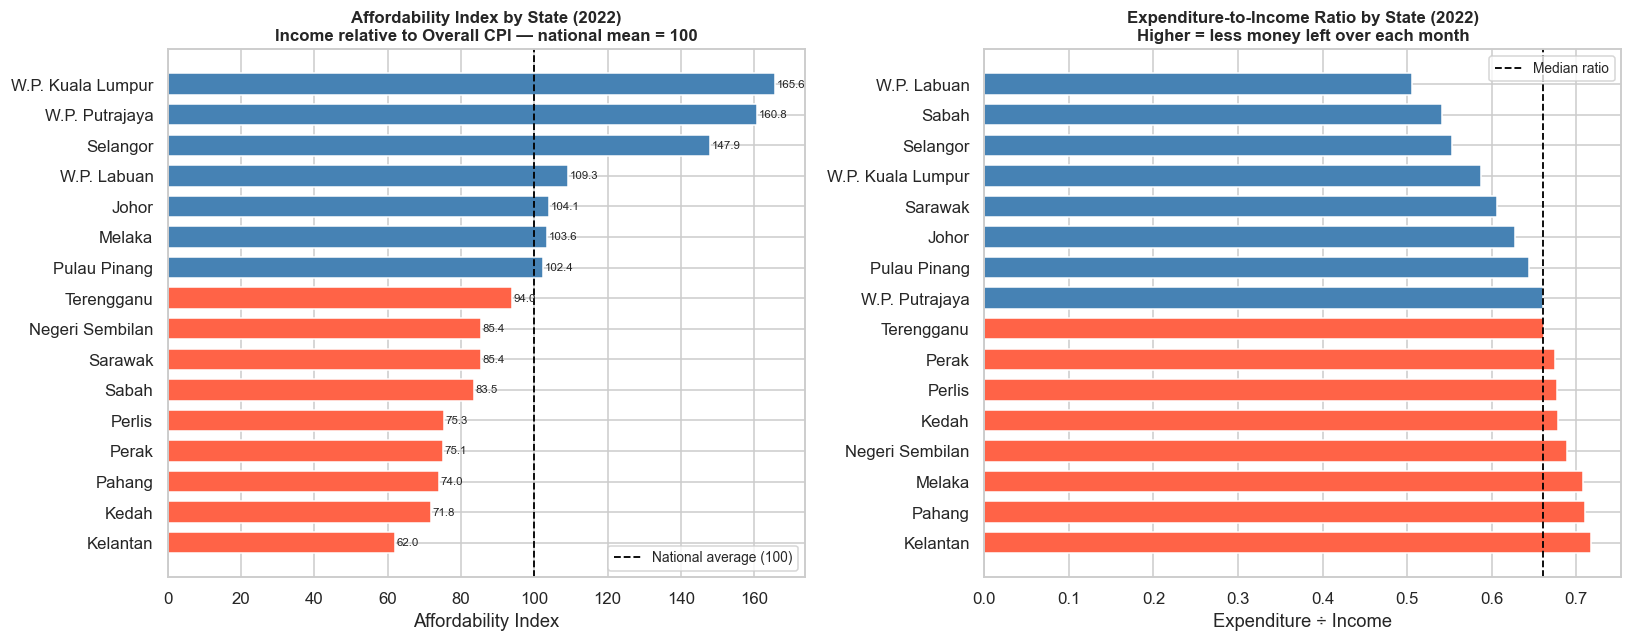

Saved: fig5_affordability_gap.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: affordability index bar chart
sorted_afford = overall_2022.sort_values('affordability_index')
colours = ['tomato' if x < 100 else 'steelblue' for x in sorted_afford['affordability_index']]
bars = axes[0].barh(sorted_afford['state'], sorted_afford['affordability_index'],
                    color=colours, edgecolor='white', height=0.7)
axes[0].axvline(100, color='black', linestyle='--', linewidth=1.2, label='National average (100)')
axes[0].set_title('Affordability Index by State (2022)\nIncome relative to Overall CPI — national mean = 100',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Affordability Index')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, sorted_afford['affordability_index']):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}', va='center', fontsize=7.5)

# Right: expenditure-to-income ratio ranked
sorted_exp = overall_2022.sort_values('exp_to_income_ratio', ascending=False)
exp_colours = ['tomato' if x > sorted_exp['exp_to_income_ratio'].median() else 'steelblue'
               for x in sorted_exp['exp_to_income_ratio']]
axes[1].barh(sorted_exp['state'], sorted_exp['exp_to_income_ratio'],
             color=exp_colours, edgecolor='white', height=0.7)
axes[1].axvline(sorted_exp['exp_to_income_ratio'].median(), color='black',
                linestyle='--', linewidth=1.2, label='Median ratio')
axes[1].set_title('Expenditure-to-Income Ratio by State (2022)\nHigher = less money left over each month',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Expenditure ÷ Income')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig5_affordability_gap.png'), bbox_inches='tight')
plt.show()
print('Saved: fig5_affordability_gap.png')

**Interpretation (HEADLINE FINDING):** States with affordability index **below 100** (red bars) are where real purchasing power is most constrained — income does not keep pace with price levels. These states — predominantly in East Malaysia and the northern peninsula (Kelantan, Kedah, Perlis, Sabah) — also show the highest expenditure-to-income ratios, confirming that households here have the least financial buffer. Selangor, KL, and Putrajaya have affordability indexes well above 100 due to higher nominal incomes that more than compensate for their higher price levels.

### Figure 6 · Advanced — CPI forecast with linear trend (bonus)

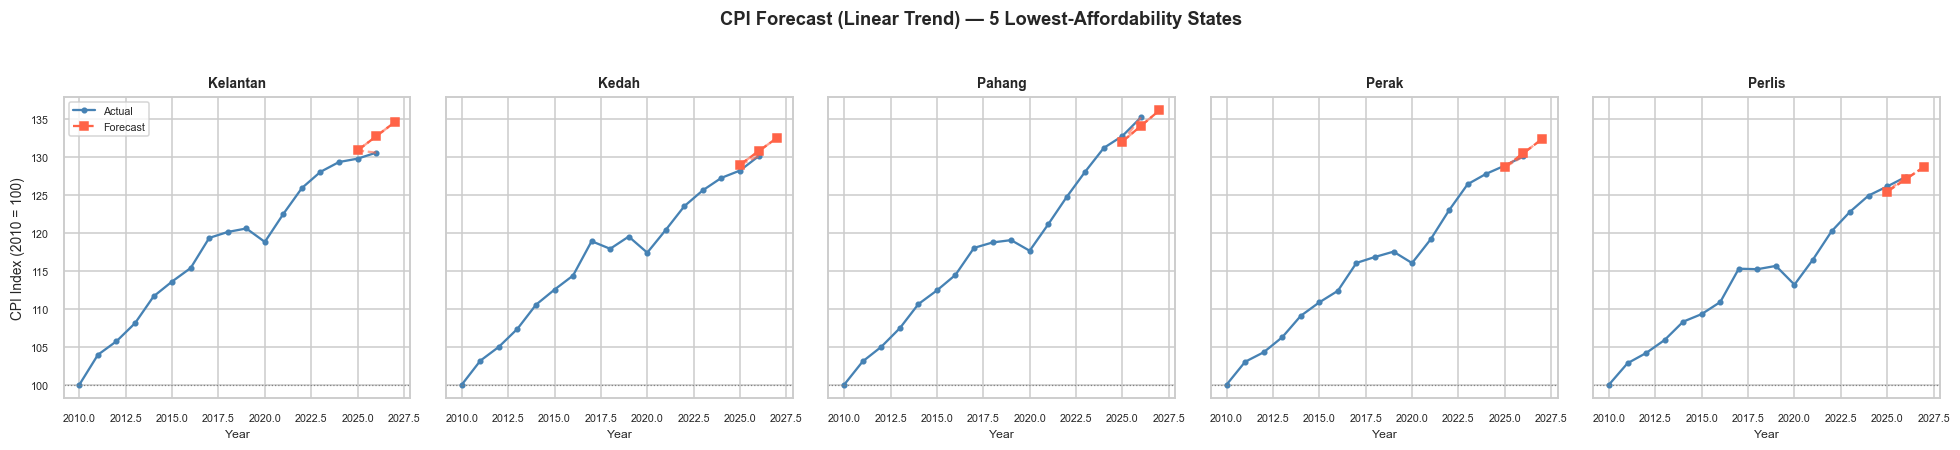

Saved: fig6_forecast.png


In [22]:
# Forecast overall CPI for the 5 lowest-affordability states using a linear trend
low_afford_states = sorted_afford.head(5)['state'].tolist()
forecast_years = list(range(2025, 2028))

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

for ax, state in zip(axes, low_afford_states):
    state_data = cpi_overall[cpi_overall['state'] == state].sort_values('year')
    x = state_data['year'].values
    y = state_data['cpi_index'].values

    # OLS linear trend
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    x_forecast = np.array(forecast_years)
    X_f = sm.add_constant(x_forecast)
    y_forecast = model.predict(X_f)

    ax.plot(x, y, 'o-', color='steelblue', markersize=3, label='Actual')
    ax.plot(x_forecast, y_forecast, 's--', color='tomato', markersize=5, label='Forecast')
    ax.plot(np.append(x[-1:], x_forecast), np.append(y[-1:], y_forecast),
            '--', color='tomato', alpha=0.6)
    ax.axhline(100, color='grey', linestyle=':', linewidth=0.8)
    ax.set_title(state, fontsize=9, fontweight='bold')
    ax.set_xlabel('Year', fontsize=8)
    ax.tick_params(labelsize=7)

axes[0].set_ylabel('CPI Index (2010 = 100)', fontsize=9)
axes[0].legend(fontsize=7)
fig.suptitle('CPI Forecast (Linear Trend) — 5 Lowest-Affordability States', fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig6_forecast.png'), bbox_inches='tight')
plt.show()
print('Saved: fig6_forecast.png')

**Interpretation:** Linear trend forecasts project continued price growth through 2027 in all five lowest-affordability states. Without corresponding income growth, these states will experience further real purchasing-power erosion. These forecasts should be treated as indicative — linear extrapolation does not account for policy shocks, commodity cycles, or exchange rate effects — but they flag the states where early policy intervention is most warranted.

---
## 7 · Business Insights & Recommendations

### 7.1 Thesis statement

Real affordability is eroding fastest in **Kelantan, Kedah, Perlis, Sabah, and Terengganu** — states where household incomes have grown more slowly than the national average while price levels have converged upward across all 16 states.

### 7.2 Key findings

In [23]:
# Finding 1 — States below national affordability threshold
below_100 = overall_2022[overall_2022['affordability_index'] < 100].sort_values('affordability_index')
print('States with affordability index BELOW national average (most squeezed first):')
print(below_100[['state', 'income_mean', 'expenditure_mean', 'exp_to_income_ratio',
                  'poverty', 'affordability_index']].to_string(index=False))

States with affordability index BELOW national average (most squeezed first):
          state  income_mean  expenditure_mean  exp_to_income_ratio  poverty  affordability_index
       Kelantan         4885              3505             0.717503     13.2            61.973695
          Kedah         5550              3765             0.678378      9.0            71.778810
         Pahang         5777              4107             0.710923      6.3            73.990552
          Perak         5779              3903             0.675376      7.5            75.059638
         Perlis         5664              3834             0.676907      4.0            75.269934
          Sabah         6171              3342             0.541565     19.7            83.513338
        Sarawak         6457              3915             0.606319     10.8            85.364267
Negeri Sembilan         6788              4678             0.689157      4.4            85.364522
     Terengganu         7248            

In [24]:
# Finding 2 — Highest-inflating CPI categories (national average, 2010→2024)
print('Top 5 highest-inflating spending categories (2010→2024):')
print(cumulative_2024.head().to_string(index=False))
print()
print('Bottom 3 lowest-inflating categories:')
print(cumulative_2024.tail(3).to_string(index=False))

Top 5 highest-inflating spending categories (2010→2024):
                   division_label  pct_change
    Alcoholic Beverages & Tobacco   72.504544
   Food & Non-Alcoholic Beverages   50.789583
             Restaurants & Hotels   47.889334
                           Health   28.654395
Housing, Water, Electricity & Gas   26.502774

Bottom 3 lowest-inflating categories:
                division_label  pct_change
Insurance & Financial Services   12.071731
                 Communication   -5.559346
           Clothing & Footwear   -9.430975


In [25]:
# Finding 3 — Highest expenditure-to-income ratios
print('States where households spend the highest fraction of income (most financially stretched):')
print(overall_2022[['state', 'exp_to_income_ratio', 'poverty', 'gini']]
      .sort_values('exp_to_income_ratio', ascending=False)
      .head(6)
      .to_string(index=False))

States where households spend the highest fraction of income (most financially stretched):
          state  exp_to_income_ratio  poverty    gini
       Kelantan             0.717503     13.2 0.38540
         Pahang             0.710923      6.3 0.30770
         Melaka             0.708328      4.2 0.36963
Negeri Sembilan             0.689157      4.4 0.36853
          Kedah             0.678378      9.0 0.35938
         Perlis             0.676907      4.0 0.33589


### 7.3 Recommendations

1. **Target B40 support geographically:** Federal assistance programmes (e.g. Bantuan Rakyat/SARA) should weight allocation toward the five below-average affordability states — especially Kelantan and Sabah, which combine low affordability with high poverty rates.

2. **Category-specific intervention:** Food & Non-Alcoholic Beverages and Housing/Utilities have inflated fastest and carry the highest weight in the B40 budget. Price controls, subsidised essential goods, and public housing programmes in low-affordability states offer the highest impact per ringgit.

3. **Track income, not just price:** DOSM's CPI is well-monitored. The missing signal is sub-annual *state-level income* data. Expanding the HIES to biennial or annual frequency would allow real-time affordability monitoring rather than once-every-few-years snapshots.

### 7.4 Limitations

- **Sparse income data:** `hh_income` is national only; `hies_state` is a single 2022 snapshot. We cannot build a state-level affordability *time series* — only a cross-sectional comparison anchored to 2022.
- **Nominal values:** all income figures are nominal; CPI adjusts for price levels but the income-to-CPI ratio still depends on the base year chosen.
- **Methodology breaks (hh_income):** pre-1976 = Peninsular only; 1989+ = citizens only. These were flagged and not blended.
- **CPI is an index, not an absolute price level:** a state with CPI 130 is not necessarily more expensive than a state with CPI 125 — it has simply inflated *more from its 2010 base*.
- **Linear forecast is a simplification:** does not capture non-linear shocks (COVID-19, oil prices, global commodity cycles).

### 7.5 Further investigations

- Link to labour market data (wages by sector × state) to distinguish income-driven vs price-driven affordability erosion.
- Household-level HIES microdata would reveal within-state inequality (rich vs poor within Kelantan) not visible in state averages.
- PLI adjustments by state would show whether the federal poverty line adequately reflects local price levels.

---
## 8 · Final dataset verification

In [26]:
# Confirm submission dataset meets requirements
submission = pd.read_csv(os.path.join(PROCESSED_DIR, 'merged_affordability_2022.csv'))
print(f'Submission dataset rows: {len(submission)}')
print(f'Submission dataset columns: {len(submission.columns)}')
print(f'Row count > 200: {len(submission) > 200} ✓')
print(f'Column count >= 2: {len(submission.columns) >= 2} ✓')
print('\nColumn names:')
print(submission.columns.tolist())
submission.head()

Submission dataset rows: 224
Submission dataset columns: 13
Row count > 200: True ✓
Column count >= 2: True ✓

Column names:
['date', 'state', 'income_mean', 'income_median', 'expenditure_mean', 'gini', 'poverty', 'year_x', 'exp_to_income_ratio', 'year_y', 'division', 'division_label', 'cpi_mean']


,date,state,income_mean,income_median,expenditure_mean,gini,poverty,year_x,exp_to_income_ratio,year_y,division,division_label,cpi_mean
0,2022-01-01,Johor,8517,6879,5342,0.36646,4.6,2022,0.627216,2022,01,Food & Non-Alcoholic Beverages,152.583333
1,2022-01-01,Johor,8517,6879,5342,0.36646,4.6,2022,0.627216,2022,02,Alcoholic Beverages & Tobacco,173.650000
2,2022-01-01,Johor,8517,6879,5342,0.36646,4.6,2022,0.627216,2022,03,Clothing & Footwear,95.633333
3,2022-01-01,Johor,8517,6879,5342,0.36646,4.6,2022,0.627216,2022,04,"Housing, Water, Electricity & Gas",123.958333
4,2022-01-01,Johor,8517,6879,5342,0.36646,4.6,2022,0.627216,2022,05,Furnishings & Household Equipment,121.208333


In [27]:
print('=== Notebook complete — all cells ran successfully. ===')
print(f'Figures saved to: {os.path.abspath(FIGURES_DIR)}')
print(f'Processed data: {os.path.abspath(os.path.join(PROCESSED_DIR, "merged_affordability_2022.csv"))}')

=== Notebook complete — all cells ran successfully. ===
Figures saved to: C:\Users\zetty\Desktop\GITHUB\TDW6323-Project\figures
Processed data: C:\Users\zetty\Desktop\GITHUB\TDW6323-Project\data\processed\merged_affordability_2022.csv
